# Exploratory Data Analysis of Facebook Post Performance

This notebook explores engagement patterns in Facebook posts to understand which types of posts perform better.

## 1. Data Loading

Load the Facebook analytics dataset and inspect its structure.

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

data_path = Path("../data/facebook_posts.csv")

df = pd.read_csv(data_path)

df.head()

,Post ID,Page ID,Page name,Title,Duration (sec),Publish time,Permalink,Post type,Data comment,Date,...,Comments,Distribution,Impressions,Interactions,Reactions,Saves,Shares,Viewers,Average Seconds viewed,Seconds viewed
0,10235051703501121,1461428297,Liz Izakson Mashal,#זהו_זה_קורה!\n\nספטמבר מביא איתו התחלות חדשות...,0,09/01/2025 22:26,https://www.facebook.com/liz.izakson/posts/pfb...,Photo,NaN,Lifetime,...,57.0,--,1479.0,126.0,102.0,0.0,6.0,1182.0,NaN,NaN
1,10237757303779437,1461428297,Liz Izakson Mashal,אתמול כתבתי כאן על החוויות ממפגש החתימות במודי...,0,03/04/2026 09:50,https://www.facebook.com/liz.izakson/posts/pfb...,Content,NaN,Lifetime,...,0.0,NaN,NaN,1.0,1.0,0.0,0.0,25.0,NaN,NaN
2,10237757281258874,1461428297,Liz Izakson Mashal,"⁨ ⁨ רגע לפני שהמלחמה התחילה והכל נסגר,\nוהתכנס...",29,03/04/2026 09:49,https://www.facebook.com/reel/2482153035588530/,Reel,NaN,Lifetime,...,0.0,-0.3x,140.0,8.0,8.0,0.0,1.0,127.0,7.255,1073.74
3,10237734887059033,1461428297,Liz Izakson Mashal,"רגע לפני שהתחילה עוד מלחמה שסוגרת אותנו בבתים,...",0,03/03/2026 09:15,https://www.facebook.com/liz.izakson/posts/pfb...,Photo,NaN,Lifetime,...,11.0,--,599.0,35.0,25.0,0.0,0.0,516.0,NaN,NaN
4,10237705072153679,1461428297,Liz Izakson Mashal,"בין הריצות לממ״ד לדאגה הקיומית,\n\nנתקלתי בסקי...",0,03/01/2026 08:58,https://www.facebook.com/liz.izakson/posts/pfb...,Content,NaN,Lifetime,...,2.0,--,197.0,14.0,13.0,0.0,0.0,160.0,NaN,NaN


## 2. Initial Data Inspection

Inspect the dataset structure, column names, and data types.

In [2]:
df.columns

Index(['Post ID', 'Page ID', 'Page name', 'Title', 'Duration (sec)',
       'Publish time', 'Permalink', 'Post type', 'Data comment', 'Date',
       'Views', 'Comments', 'Distribution', 'Impressions', 'Interactions',
       'Reactions', 'Saves', 'Shares', 'Viewers', 'Average Seconds viewed',
       'Seconds viewed'],
      dtype='object')

In [3]:
df.head()
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Post ID                 111 non-null    int64  
 1   Page ID                 111 non-null    int64  
 2   Page name               111 non-null    object 
 3   Title                   111 non-null    object 
 4   Duration (sec)          111 non-null    int64  
 5   Publish time            111 non-null    object 
 6   Permalink               111 non-null    object 
 7   Post type               111 non-null    object 
 8   Data comment            0 non-null      float64
 9   Date                    111 non-null    object 
 10  Views                   111 non-null    int64  
 11  Comments                79 non-null     float64
 12  Distribution            78 non-null     object 
 13  Impressions             78 non-null     float64
 14  Interactions            79 non-null     fl

In [4]:
pd.set_option("display.max_colwidth", None)

df["Title"].iloc[0]

'#זהו_זה_קורה!\n\nספטמבר מביא איתו התחלות חדשות.\n\nהילדים חוזרים למסגרות (סופסוף:)), שנה חדשה בפתח, אולי התחלתם אפילו לימודים או עבודה חדשה.\n\nוהנה עכשיו גם #בין_המסדרונות סופסוף נולד!\n\nוזה משמח ומרגש, וכן גם מפחיד מאוד:)\n\nשמחה לספר שאתר evrit - עברית בחרו בו כחלק מנבחרי החודש!\n\nאז אם בא לכם להיכנס לעולמה של אלי שחוקרת חיבורים בין אנשים בהווה ומתמודדת עם שאלות של זהות בפנימייה בעבר, אתם מוזמנים לרכוש אותו במבצע מיוחד (דיגיטלי או מודפס).\n\nומקווה שגם אתכם הוא יעביר מסע בין מסדרונות העבר להווה:)\n\nהלינק בתגובות 👇\n\nהתחנה - בית הוצאה לאור  Orna Landau'

## 3. Data Cleaning

Convert columns names (normalize) and convert columns that should contain numeric values and inspect missing values.

In [5]:
# Column name cleaning
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace(r"[^\w]+", "_", regex=True)
             )

df.columns

Index(['post_id', 'page_id', 'page_name', 'title', 'duration_sec_',
       'publish_time', 'permalink', 'post_type', 'data_comment', 'date',
       'views', 'comments', 'distribution', 'impressions', 'interactions',
       'reactions', 'saves', 'shares', 'viewers', 'average_seconds_viewed',
       'seconds_viewed'],
      dtype='object')

In [6]:
df.dtypes

post_id                     int64
page_id                     int64
page_name                  object
title                      object
duration_sec_               int64
publish_time               object
permalink                  object
post_type                  object
data_comment              float64
date                       object
views                       int64
comments                  float64
distribution               object
impressions               float64
interactions              float64
reactions                 float64
saves                     float64
shares                    float64
viewers                   float64
average_seconds_viewed    float64
seconds_viewed            float64
dtype: object

In [7]:
df["post_type"].value_counts()

post_type
Photo      86
Content    18
Reel        6
Link        1
Name: count, dtype: int64

In [8]:
# Columns that should contain numeric values
numeric_cols = [
    "views",
    "comments",
    "impressions",
    "interactions",
    "reactions",
    "saves",
    "shares",
    "viewers",
    "average_seconds_viewed",
    "seconds_viewed"
]

# Convert columns to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

## 4. Missing Value Inspection

Check which variables contain missing values and understand whether they represent true missing data or non-applicable metrics.

In [9]:
# Check how many missing values exist in each column
df[numeric_cols].isna().sum()

views                       0
comments                   32
impressions                33
interactions               32
reactions                  32
saves                      32
shares                     32
viewers                    32
average_seconds_viewed    105
seconds_viewed            105
dtype: int64

## 5. Investigating Missing Video Metrics

Examine whether video-related metrics (e.g., viewing time) are missing because they are only relevant for video posts.

In [10]:
df.groupby("post_type")[[
"average_seconds_viewed",
"seconds_viewed"
]].count()

,average_seconds_viewed,seconds_viewed
post_type,,
Content,0,0
Link,0,0
Photo,0,0
Reel,6,6


## 6. Parsing Date and Time Variables

Convert the publish time to datetime and extract useful temporal features such as hour and weekday.

In [11]:
# Convert publish_time column to datetime
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")

# Extract time features
df["hour"] = df["publish_time"].dt.hour
df["weekday"] = df["publish_time"].dt.day_name()

df[["publish_time","hour","weekday"]].head()

,publish_time,hour,weekday
0,2025-09-01 22:26:00,22,Monday
1,2026-03-04 09:50:00,9,Wednesday
2,2026-03-04 09:49:00,9,Wednesday
3,2026-03-03 09:15:00,9,Tuesday
4,2026-03-01 08:58:00,8,Sunday


In [12]:
# Extract useful time features
df["date"] = df["publish_time"].dt.date
df["time"] = df["publish_time"].dt.time
df["hour"] = df["publish_time"].dt.hour
df["weekday"] = df["publish_time"].dt.day_name()

In [13]:
df_check = df[[
    "date",
    "time",
    "weekday",
    "title"
]]

In [14]:
df_check.sort_values("date", ascending=False).head(20)

,date,time,weekday,title
1,2026-03-04,09:50:00,Wednesday,"אתמול כתבתי כאן על החוויות ממפגש החתימות במודיעין, \nרגע לפני שהכול נסגר.\n\nאלה כמה רגעים מאחורי הקלעים.\n\nוהמחסן, שהוא חלק עיקרי מהשקט שאני צריכה לפני שאני ניגשת לאנשים:)\n\n#בין_המסדרונות #ספרים #ספרביכורים #מאחוריהקלעים #צומתספרים"
2,2026-03-04,09:49:00,Wednesday,"⁨ ⁨ רגע לפני שהמלחמה התחילה והכל נסגר,\nוהתכנסנו שוב בממ״ד/מקלט,\nהספקתי לעמוד ליד ערימת הספרים שלי\nולדבר עם אנשים פנים אל פנים.\nבלי מסך בינינו.\n(אבל קודם ביליתי כמה דקות במחסן כדי להיטען,\nאין על מחסנים של חנויות ספרים )\n\nלמי שמתחשק קצת אסקפיזם, לינק לעותק הדיגיטלי בביו. \nקודי קופון להנחות נוספות: LIZIZ10, realbooks\n\n#בין_המסדרונות #ספרים #ספרותעברית #ספרביכורים #פנימייה \n\n‪‪@tzometsfarim‪@hatachana_publishing‪@lior_sharf‬harf‬harf⁩⁩"
3,2026-03-03,09:15:00,Tuesday,"רגע לפני שהתחילה עוד מלחמה שסוגרת אותנו בבתים, \n\nמדביקה למסכים ומכניסה לדאגה קיומית,\n\nהספקתי לצאת לשטח ולנהל כמה שיחות פנים אל פנים עם קוראים.\n\nאני אוהבת לפגוש אנשים ככה. \nיש תמיד תחלופה אנרגטית שמתרחשת,\nוכשמדברים על ספרים, נחשפים רבדים.\n\nכי בסוף אנחנו בוחרים ספרים לפי מה שמדבר אותנו הכי עמוק.\n\nקודם כול גיליתי שמודיעין לא כזאת רחוקה ממני בשישי בבוקר.\n\nוהפעם גם יישמתי משהו שלמדתי על עצמי:\nלפני שאני פונה לאנשים, אני צריכה כמה רגעים לבד. לנשום.\nהמחסן של החנות הוא מקום אידיאלי לזה.\n\nאחרי שאני נטענת במחסן, אני עומדת ליד ערימת הספרים שלי \nוצופה באנשים שנכנסים ויוצאים.\n\nחנויות ספרים הן מקום בריחה.\nאז אני מנסה לקרוא שפת גוף.\nמי מחפש שקט, מי ממהר, ומי פתוח לשיחה על ספר חדש.\n\nכשאני כבר נכנסת למצב תודעה של “מחכים לגודו”, אני מכריחה את עצמי ליזום שיחה עם האדם הראשון שעובר לידי.\n\nהפעם זה היה בחור שלא מסתכל בעיניים. כזה שהעיניים שלו בורחות לכל הכיוונים.\nאני מחייכת ומספרת על #בין_המסדרונות. \nאני יודעת שהוא לא באמת מתעניין בו, הוא רוצה לספר לי על הצרות שלו בדייטים.\nואני מקשיבה, ותוהה אם להציע לו להסתכל יותר בעיניים.\n\nבזמן השיחה שלנו, שתי בחורות יוצאות מהתור לקופה ומתעניינות:\n“את כתבת ספר? על מה הספר?”\nאני מספרת. הן רוכשות. מבקשות הקדשה.\n\nואז האנרגיה הזאת, של האינטראקציות הראשונות, של ספר שמייצר חיבור ראשוני, מייצרת עוד אנרגיה לפנות, לשתף, להקשיב.\n\nאני עדיין בוחרת בזהירות למי לפנות. כדי לשמר אנרגיה.\nאני רוצה להקדיש תשומת לב לכל שיחה, וזה דורש משאבים.\n\nאמא ובת מגיעות עם רצון משותף לקרוא.\nהאמא מבקשת רגע לעיין.\nזה רגע לא קל כיוצרת - לראות את היצירה שלך נשפטת מול העיניים.\nאני נושמת ומזכירה לעצמי: היא טובה כמו שהיא.\nהיא מחליטה לקחת אותה ושואלת איך היה להיות בפנימיית בויאר.\n\nבחור גבוה עובר ושואל עד כמה הספר מבוסס על אירועים אמיתיים.\nזה בהשראתם, אני עונה. \nהוא התחיל מאירועים אמיתיים, אבל התפתח לדמיון, כדי לשחרר את הדמויות לעולם שלהן.\n\nועוד ועוד אנשים.\nעם חלקם זה נגמר בחיוך ושלום,\nוחלקם לוקחים את הספר ומשאירים אצלי פיסת מידע עליהם.\nואני יודעת שהספר בידיים טובות.\n\nובסוף תמיד יש את האדם הזה,\nשהאינטראקציה איתו פשוט נועדה לקרות.\nאנחנו משדרות על אותו גל כבר מהמשפטים הראשונים.\nהיא רוצה את הספר, אבל גם ספר לכל אחד מבני המשפחה שלה.\nואני מגלה תחביב חדש,\nלחבר ספר לפי תיאור אישיות.\n\nאני חוזרת הביתה עייפה ומותשת,\nאבל מלאה.\nבעסקת חליפין של אנרגיות, סיפורים, מבטים,\nובתחושה שגם בתוך מציאות מטלטלת,\nהמפגש האנושי עוד קיים.\n\nותודה לצוות המקסים של צומת ספרים במודיעין \nעל תחושת הבית,\nועל המחסן שמאפשר טעינת אנרגיות למי שצריך.\n\nולמי שמתחשק רגע של אסקפיזם,\nהשארתי לינק בתגובות.\n\nהתחנה - בית הוצאה לאור Orna Landau Dan Winocour ליאור שרף צומת ספרים"
4,2026-03-01,08:58:00,Sunday,"בין הריצות לממ״ד לדאגה הקיומית,\n\nנתקלתי בסקירה המרגשת של שירז על #בין_המסדרונות.\n\n״תחושת הקריאה הייתה אותנטית מאוד, אוטוביוגרפית ממש, \nבעיקר בתיאור של הווי הפנימיה וההערכה העצמית הפריכה של הגיבורה. \nהספר עניין ומתח אותי לכל אורכו, לא במובן של תעלומת רצח \nאלא של רצון לקרוא את השלב הבא בהשתלשלות האירועים.״\n\nתודה לך על קריאה מעמיקה ורגישה,\nועל מילים שמזכירות לי שלספר יש חיים משלו בעולם.\n\nהפוסט המלא שלה מצורף כאן ⬇️\n\nולמי שמתחשק רגע לברוח אל מסדרונות האבן של הפנימייה,\nולשאול מה גורם לנו להתחבר דווקא לאנשים מסוימים,\nהספר מחכה באתר עברית (לינק בתגובות),\nובחנויות הספרים, כשייפתחו שוב...\n\nShiraz Afik\n\nהתחנה - בית הוצאה לאו

### Timestamp Correction

The exported Facebook timestamps were shifted by +10 hours to match the actual posting times observed on the platform.

In [18]:
df["publish_time"] = df["publish_time"] + pd.Timedelta(hours=10)

In [19]:
df["date"] = df["publish_time"].dt.date
df["time"] = df["publish_time"].dt.time
df["hour"] = df["publish_time"].dt.hour
df["weekday"] = df["publish_time"].dt.day_name()

In [20]:
df.sort_values("publish_time", ascending=False)[
    ["date","time","weekday","title"]
].head(10)

,date,time,weekday,title
1,2026-03-04,19:50:00,Wednesday,"אתמול כתבתי כאן על החוויות ממפגש החתימות במודיעין, \nרגע לפני שהכול נסגר.\n\nאלה כמה רגעים מאחורי הקלעים.\n\nוהמחסן, שהוא חלק עיקרי מהשקט שאני צריכה לפני שאני ניגשת לאנשים:)\n\n#בין_המסדרונות #ספרים #ספרביכורים #מאחוריהקלעים #צומתספרים"
2,2026-03-04,19:49:00,Wednesday,"⁨ ⁨ רגע לפני שהמלחמה התחילה והכל נסגר,\nוהתכנסנו שוב בממ״ד/מקלט,\nהספקתי לעמוד ליד ערימת הספרים שלי\nולדבר עם אנשים פנים אל פנים.\nבלי מסך בינינו.\n(אבל קודם ביליתי כמה דקות במחסן כדי להיטען,\nאין על מחסנים של חנויות ספרים )\n\nלמי שמתחשק קצת אסקפיזם, לינק לעותק הדיגיטלי בביו. \nקודי קופון להנחות נוספות: LIZIZ10, realbooks\n\n#בין_המסדרונות #ספרים #ספרותעברית #ספרביכורים #פנימייה \n\n‪‪@tzometsfarim‪@hatachana_publishing‪@lior_sharf‬harf‬harf⁩⁩"
3,2026-03-03,19:15:00,Tuesday,"רגע לפני שהתחילה עוד מלחמה שסוגרת אותנו בבתים, \n\nמדביקה למסכים ומכניסה לדאגה קיומית,\n\nהספקתי לצאת לשטח ולנהל כמה שיחות פנים אל פנים עם קוראים.\n\nאני אוהבת לפגוש אנשים ככה. \nיש תמיד תחלופה אנרגטית שמתרחשת,\nוכשמדברים על ספרים, נחשפים רבדים.\n\nכי בסוף אנחנו בוחרים ספרים לפי מה שמדבר אותנו הכי עמוק.\n\nקודם כול גיליתי שמודיעין לא כזאת רחוקה ממני בשישי בבוקר.\n\nוהפעם גם יישמתי משהו שלמדתי על עצמי:\nלפני שאני פונה לאנשים, אני צריכה כמה רגעים לבד. לנשום.\nהמחסן של החנות הוא מקום אידיאלי לזה.\n\nאחרי שאני נטענת במחסן, אני עומדת ליד ערימת הספרים שלי \nוצופה באנשים שנכנסים ויוצאים.\n\nחנויות ספרים הן מקום בריחה.\nאז אני מנסה לקרוא שפת גוף.\nמי מחפש שקט, מי ממהר, ומי פתוח לשיחה על ספר חדש.\n\nכשאני כבר נכנסת למצב תודעה של “מחכים לגודו”, אני מכריחה את עצמי ליזום שיחה עם האדם הראשון שעובר לידי.\n\nהפעם זה היה בחור שלא מסתכל בעיניים. כזה שהעיניים שלו בורחות לכל הכיוונים.\nאני מחייכת ומספרת על #בין_המסדרונות. \nאני יודעת שהוא לא באמת מתעניין בו, הוא רוצה לספר לי על הצרות שלו בדייטים.\nואני מקשיבה, ותוהה אם להציע לו להסתכל יותר בעיניים.\n\nבזמן השיחה שלנו, שתי בחורות יוצאות מהתור לקופה ומתעניינות:\n“את כתבת ספר? על מה הספר?”\nאני מספרת. הן רוכשות. מבקשות הקדשה.\n\nואז האנרגיה הזאת, של האינטראקציות הראשונות, של ספר שמייצר חיבור ראשוני, מייצרת עוד אנרגיה לפנות, לשתף, להקשיב.\n\nאני עדיין בוחרת בזהירות למי לפנות. כדי לשמר אנרגיה.\nאני רוצה להקדיש תשומת לב לכל שיחה, וזה דורש משאבים.\n\nאמא ובת מגיעות עם רצון משותף לקרוא.\nהאמא מבקשת רגע לעיין.\nזה רגע לא קל כיוצרת - לראות את היצירה שלך נשפטת מול העיניים.\nאני נושמת ומזכירה לעצמי: היא טובה כמו שהיא.\nהיא מחליטה לקחת אותה ושואלת איך היה להיות בפנימיית בויאר.\n\nבחור גבוה עובר ושואל עד כמה הספר מבוסס על אירועים אמיתיים.\nזה בהשראתם, אני עונה. \nהוא התחיל מאירועים אמיתיים, אבל התפתח לדמיון, כדי לשחרר את הדמויות לעולם שלהן.\n\nועוד ועוד אנשים.\nעם חלקם זה נגמר בחיוך ושלום,\nוחלקם לוקחים את הספר ומשאירים אצלי פיסת מידע עליהם.\nואני יודעת שהספר בידיים טובות.\n\nובסוף תמיד יש את האדם הזה,\nשהאינטראקציה איתו פשוט נועדה לקרות.\nאנחנו משדרות על אותו גל כבר מהמשפטים הראשונים.\nהיא רוצה את הספר, אבל גם ספר לכל אחד מבני המשפחה שלה.\nואני מגלה תחביב חדש,\nלחבר ספר לפי תיאור אישיות.\n\nאני חוזרת הביתה עייפה ומותשת,\nאבל מלאה.\nבעסקת חליפין של אנרגיות, סיפורים, מבטים,\nובתחושה שגם בתוך מציאות מטלטלת,\nהמפגש האנושי עוד קיים.\n\nותודה לצוות המקסים של צומת ספרים במודיעין \nעל תחושת הבית,\nועל המחסן שמאפשר טעינת אנרגיות למי שצריך.\n\nולמי שמתחשק רגע של אסקפיזם,\nהשארתי לינק בתגובות.\n\nהתחנה - בית הוצאה לאור Orna Landau Dan Winocour ליאור שרף צומת ספרים"
4,2026-03-01,18:58:00,Sunday,"בין הריצות לממ״ד לדאגה הקיומית,\n\nנתקלתי בסקירה המרגשת של שירז על #בין_המסדרונות.\n\n״תחושת הקריאה הייתה אותנטית מאוד, אוטוביוגרפית ממש, \nבעיקר בתיאור של הווי הפנימיה וההערכה העצמית הפריכה של הגיבורה. \nהספר עניין ומתח אותי לכל אורכו, לא במובן של תעלומת רצח \nאלא של רצון לקרוא את השלב הבא בהשתלשלות האירועים.״\n\nתודה לך על קריאה מעמיקה ורגישה,\nועל מילים שמזכירות לי שלספר יש חיים משלו בעולם.\n\nהפוסט המלא שלה מצורף כאן ⬇️\n\nולמי שמתחשק רגע לברוח אל מסדרונות האבן של הפנימייה,\nולשאול מה גורם לנו להתחבר דווקא לאנשים מסוימים,\nהספר מחכה באתר עברית (לינק בתגובות),\nובחנויות הספרים, כשייפתחו שוב...\n\nShiraz Afik\n\nהתחנה - בית הוצאה לאו

## 7. Distribution of Engagement Metrics

In this section we examine the distribution of key engagement variables in order to understand their scale, variability, and potential skewness. This helps identify how post performance is distributed across the dataset.

In [21]:
engagement_vars = [
    "reactions",
    "comments",
    "shares",
    "saves",
    "impressions",
    "interactions"
]

df[engagement_vars].describe()

,reactions,comments,shares,saves,impressions,interactions
count,79.000000,79.000000,79.000000,79.000000,78.000000,79.000000
mean,44.164557,15.063291,0.810127,0.101266,1175.589744,55.936709
std,26.192791,11.252740,1.086938,0.411219,1618.027342,33.262878
min,1.000000,0.000000,0.000000,0.000000,140.000000,1.000000
25%,25.500000,6.500000,0.000000,0.000000,522.750000,32.500000
50%,42.000000,13.000000,1.000000,0.000000,862.500000,52.000000
75%,59.000000,20.000000,1.000000,0.000000,1160.750000,75.000000
max,118.000000,57.000000,6.000000,2.000000,12502.000000,144.000000


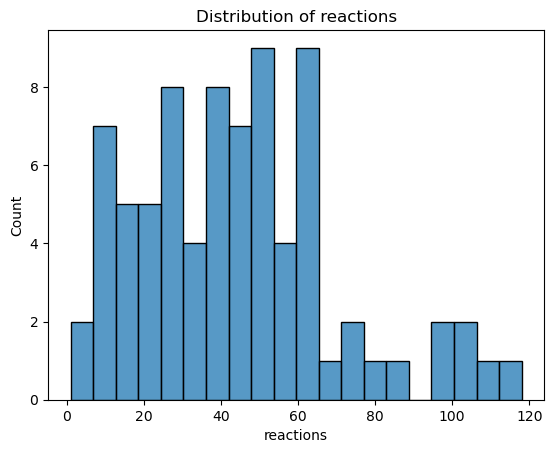

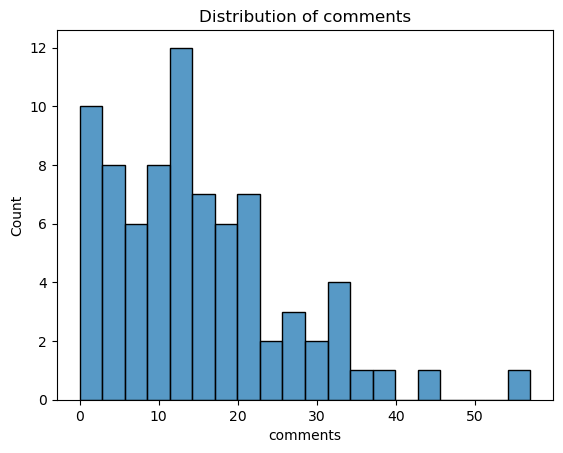

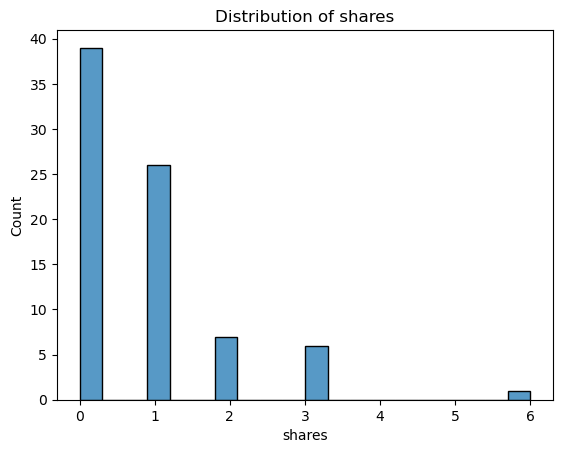

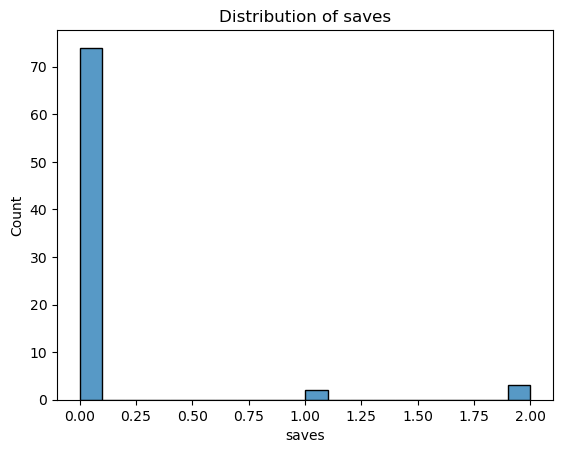

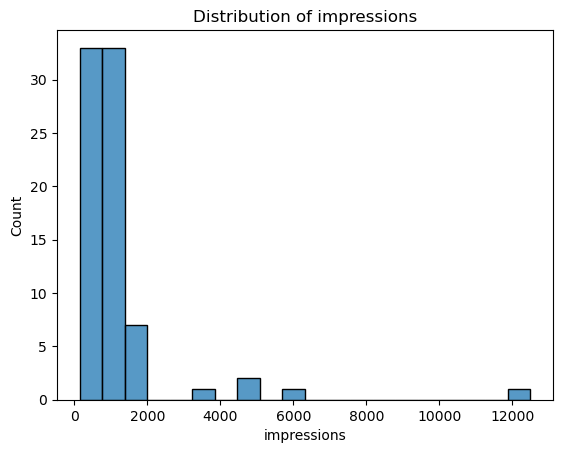

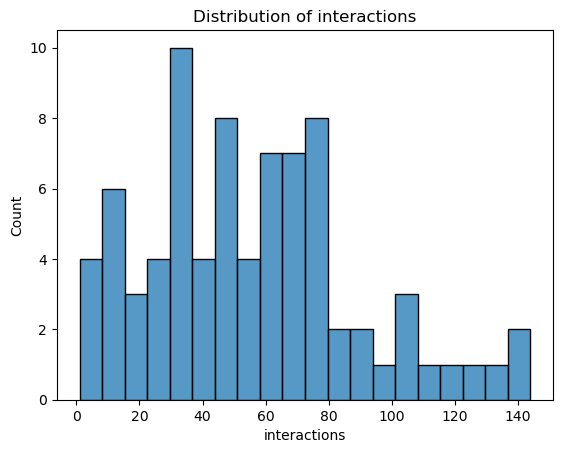

In [28]:
for var in engagement_vars:
    sns.histplot(df[var], bins=20)
    plt.title(f"Distribution of {var}")
    plt.show()

In [23]:
df["interactions"].skew()

0.6369265045658716

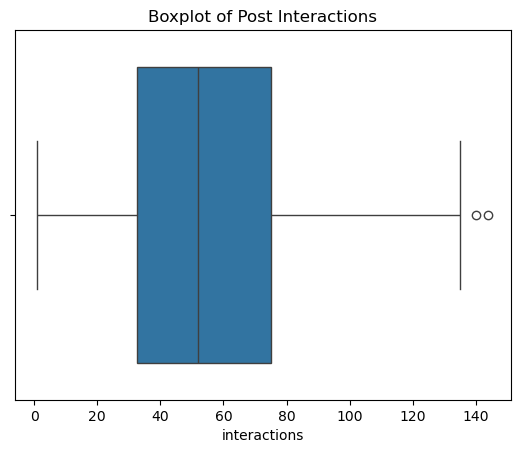

In [24]:
sns.boxplot(x=df["interactions"])

plt.title("Boxplot of Post Interactions")

plt.show()

In [25]:
df["interactions"].mean(), df["interactions"].median()

(55.936708860759495, 52.0)

In [29]:
df["interactions"] - (
    df["reactions"] +
    df["comments"] +
    df["shares"] +
    df["saves"]
)

0     -39.0
1       0.0
2      -1.0
3      -1.0
4      -1.0
       ... 
106    -5.0
107    -1.0
108   -19.0
109   -20.0
110     NaN
Length: 111, dtype: float64

In [30]:
df[["interactions","impressions"]].corr()

,interactions,impressions
interactions,1.00000,0.59116
impressions,0.59116,1.00000


### Algorithmic vs Audience Engagement

Post performance can be evaluated from two perspectives:

1. Algorithmic exposure (impressions)
2. Audience engagement relative to exposure (engagement rate)

Analyzing both allows us to distinguish between posts favored by the algorithm and posts that resonate strongly with the audience.

In [31]:
df["engagement_rate"] = df["interactions"] / df["impressions"]

In [32]:
df["impressions"].min()

140.0

In [33]:
df["engagement_rate"] = df["interactions"] / df["impressions"].replace(0, np.nan)

In [34]:
df["engagement_rate"].describe()

count    78.000000
mean      0.061747
std       0.020920
min       0.009279
25%       0.050555
50%       0.064517
75%       0.077969
max       0.113208
Name: engagement_rate, dtype: float64

In [35]:
df["engagement_rate"].skew()

-0.41822987897952835

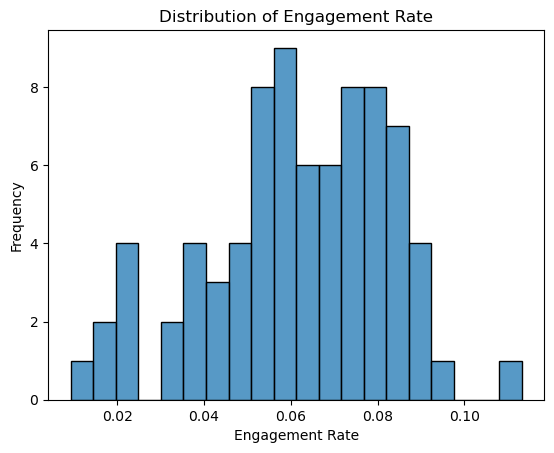

In [36]:
sns.histplot(df["engagement_rate"], bins=20)

plt.title("Distribution of Engagement Rate")
plt.xlabel("Engagement Rate")
plt.ylabel("Frequency")

plt.show()

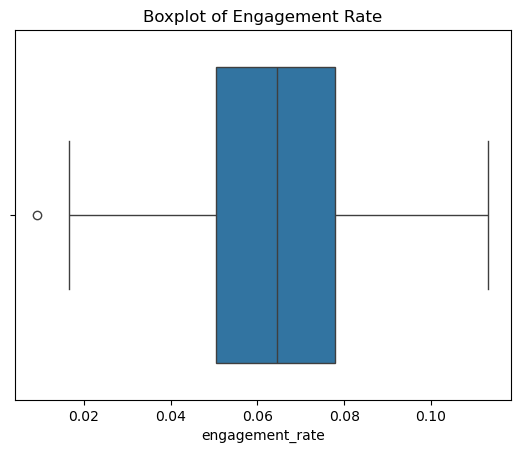

In [37]:
sns.boxplot(x=df["engagement_rate"])

plt.title("Boxplot of Engagement Rate")

plt.show()

In [39]:
df["engagement_rate"].mean(), df["engagement_rate"].median()

(0.06174655753931548, 0.06451676827071354)

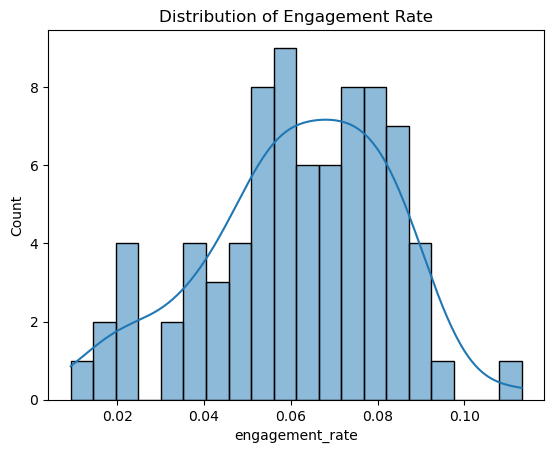

In [40]:
sns.histplot(df["engagement_rate"], bins=20, kde=True)

plt.title("Distribution of Engagement Rate")
plt.show()

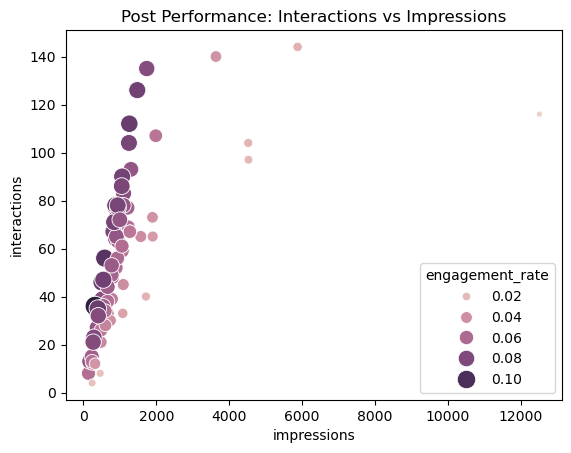

In [41]:
sns.scatterplot(
    data=df,
    x="impressions",
    y="interactions",
    hue="engagement_rate",
    size="engagement_rate",
    sizes=(20,200)
)

plt.title("Post Performance: Interactions vs Impressions")
plt.show()

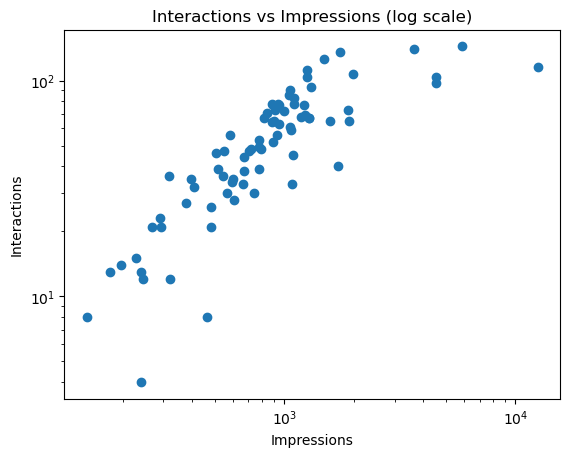

In [42]:
plt.scatter(df["impressions"], df["interactions"])
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Impressions")
plt.ylabel("Interactions")
plt.title("Interactions vs Impressions (log scale)")
plt.show()

In [43]:
df.sort_values("engagement_rate", ascending=False)[
    ["title","impressions","interactions","engagement_rate"]
].head(10)

,title,impressions,interactions,engagement_rate
28,"התרגשתי לקבל סקירה כזאת מעמיקה מ Danielle Eshel, שמזכירה לי את המקום שממנו נכתב הספר.\n\n״נחמץ לי הלב מהאירועים שהגיבורה עוברת… גם הייתי איתה בניצחונות שלה.״\n\nאחד הדברים שהיה לי הכי חשוב ליצור הוא רגע של הזדהות והטמעה בתוך אלי הגיבורה, להיכנס איתה לעולם אחר, למקום אחר, לראש שלה, ומתוך זה אולי להבין משהו קטן על עצמך.\n\nשמחה כל כך שההזדהות הזאת התרחשה אצל דניאל.\n \nומי שעוד לא קרא, הספר משתתף במבצעים של סטימצקי וצומת, \nולמי שמעדיף דיגיטל יש מבצע שווה במיוחד (עד היום) - לינק בתגובות.",318.0,36.0,0.113208
51,"לדבר בקצרה זה לא בדיוק הצד החזק שלי.\n\nאבל ביקשו ממני לבחור רק שלושה דברים על #בין_המסדרונות,\nוהנה, הלכתי, וצימצמתי… ויצא סרטון! 🎥\n\nתודה ענקית ל־Orna landau - אורנה לנדאו על הארגון,\nול־Tamara Kreitler על הצילום המדויק והרגיש.\n\nולמי שהסרטון עושה חשק, הספר מחכה לכם בסטימצקי ובצומת,\nולמי שאוהב דיגיטל - גם באתר עברית (לינק בתגובות).",585.0,56.0,0.095726
44,האם יש מתכון להתאהבות?\nקטע קצר מתוך ״בין המסדרונות״...\n\nOrna landau - אורנה לנדאו\nהתחנה - בית הוצאה לאור,505.0,46.0,0.091089
49,"זאת הייתה שנה מיוחדת ומורכבת, השנה השלושים ושש בחיי, שקצת קשה לי להיפרד ממנה.\nואולי זה כי באופן כללי אני אדם שקצת קשה לו להיפרד.\n\nזאת הייתה שנה מלאה בתהפוכות, תשוקות חדשות ואסימונים שנפלו והתגלגלו והזיזו הרבה גלגלים במוח. \n\nשנה שבה הפכתי לאמא בפעם השנייה.\nשנה שבה למדתי לתמרן בין הפעוט שלי לבין התינוק שלי לבין רגשות האשם האימהיים שמובנים בי.\nשנה שאילצה אותי להתמודד עם הרבה אתגרים (והמון חוסר שינה) במערכת היחסים שלי, אבל גם קירבה אותי עוד לאורן.\nשנה שבה הוצאתי את הספר הראשון שלי, ״בין המסדרונות״, מעין לידה שלישית.\nשנה שבה הבנתי מה זה אומר להוציא ספר בישראל.\nשנה שבה פחדתי רגע לפני שהספר יצא כי הוא כבר לא יהיה רק פוטנציאל אלא יקבל קיום ממשי אצל קוראים.\nשנה שבה התרגשתי כל-כך לראות את התגובות של מי שקרא אותו ועד היום זה מרגש אותי נורא.\n\nזו הייתה שנה שבה חיפשתי את עצמי ולמדתי לדבר את הקול שלי.\nשנה שבה למדתי לעשות קרוסלות באינסטגרם (ומי יודע אולי בשנה הבאה, אני אפילו לא אפחד מטיקטוק ולא אחשוב שהוא סופה של האנושות).\nשנה שבה הרבה חברויות מפעם חזרו לחיי והרבה חברויות חדשות נוצרו ואני מברכת על כל אחת מהן.\nשנה שבה למדתי להיות נאמנה יותר לעצמי ולמה שעושה לי טוב בחיים האלה שעוברים מהר מדי.\nשנה שחיזקתי בה את האמונה שלי כי בסוף זה הדבר הכי חשוב בחיים האלה.\nושנה שבה למדתי לאזן את הפרפקציוניסטית שבי ולהילחם בה כשצריך ויש עוד הרבה עבודה לפניי.\n\nזהו יום ההולדת הראשון שאני חוגגת בלי סבתא שלי ז״ל.\nובכל זאת, אני שמחה מכל הטוב שכן יש סביבי, כי אני יודעת שהיא הייתה רוצה בכך. \nזו הייתה שנה שבה למדתי יותר ויותר להעריך את ה״כן״ ולהיות יותר סלחנית ל״לא״.\n\nאז תודה רבה לכל מי שבירך אותי ❤️. \nמאחלת לכולנו שנה שבה נהיה חזקים ומאוחדים וכמו שגיסתי החכמה תמיד אומרת, שנדע ליהנות מהדברים הפשוטים בחיים.\n\nבתמונה - אני ביומולדת לפני שנה, רגע לפני שילדתי את בני השני, בחולצה אדומה שמסמלת עבורי את התשוקה, היופי והמורכבות שבלהיות אישה.",1260.0,112.0,0.088889
45,"יש ימים שהעולם נראה גדול מדי ואני לא מצליחה להחזיק אותו בתוכי.\n\nאולי זה קשור לחוסר המטורף בשעות שינה?\nאולי זה הצורך להיות הכל ולהספיק הכל? \nלהיות אמא מספיק טובה, סופרת מספיק טובה, אבל גם לחזור ולעבוד בעבודה ״רצינית״.\n\nלפעמים שואלים אותי מתי אני חוזרת לעבודה ״אמיתית״?\nזה תמיד קצת מצחיק אותי (או מעציב, אבל בתכלס מצחיק ומעציב בדרך-כלל הולכים ביחד), כי מה שאני עושה עכשיו מרגיש לי אמיתי ורציני מאוד. \nוזה שזה לא עומד בסטנדרטים של עבודה מסודרת ומשכורת וודאית לא אומר שזה לא רציני. \nמה גם שאין באמת שום-דבר וודאי בחיים אבל זה כבר נושא אחר.\n\nאז אולי יקח קצת זמן למצוא בחזרה את האיזון הזה.\nלהתאזן בין האמא שאני רוצה להיות, לסופרת ולחוקרת.\nאבל זאת הבחירה שלי לא לפחד מהתהליך הזה, גם כשהוא מבולגן ולא עומד בסטנדרטים שגדלתי עליהם.\nגם כשאין כרגע עבודה ״רצינית״ וגם כשנראה לי שאני לא מספיקה את כל מה שאני רוצה, \nאני רוצה ללמוד להניח לדברים להיות מה שהם.\n\nבתמונה - אני מניחה רגע לאור לנצח את החושך.\n\n#אנשי_הגם_וגם",881.0,78.0,0.088536
87,כמה מרגש לקבל סקירה כזאת מעמיקה על #בין_המסדרונות!\n\nתודה ענקית ל Raz Calmanovici על הקריאה הרגישה וההבנה לעומק של עולמה של אלי 💛,396.0,35.0,0.088384
33,"כשהייתי בת 16, הייתי לוקחת אוטובוס בקיץ מבית שמש ונוסעת לדיזינ

## Algorithmic Exposure vs Audience Engagement
To distinguish between posts favored by the algorithm and posts that resonate with the audience, we compare impressions and engagement rate.

In [44]:
impressions_mean = df["impressions"].mean()
engagement_mean = df["engagement_rate"].mean()

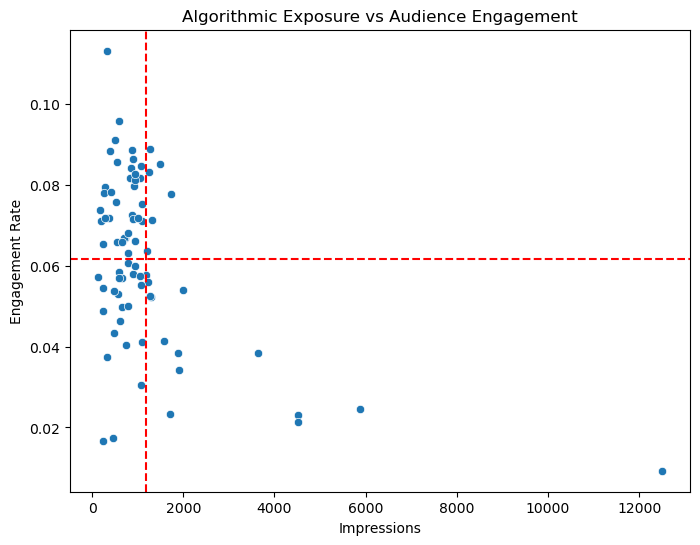

In [45]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="impressions",
    y="engagement_rate"
)

plt.axvline(impressions_mean, color="red", linestyle="--")
plt.axhline(engagement_mean, color="red", linestyle="--")

plt.xlabel("Impressions")
plt.ylabel("Engagement Rate")
plt.title("Algorithmic Exposure vs Audience Engagement")

plt.show()

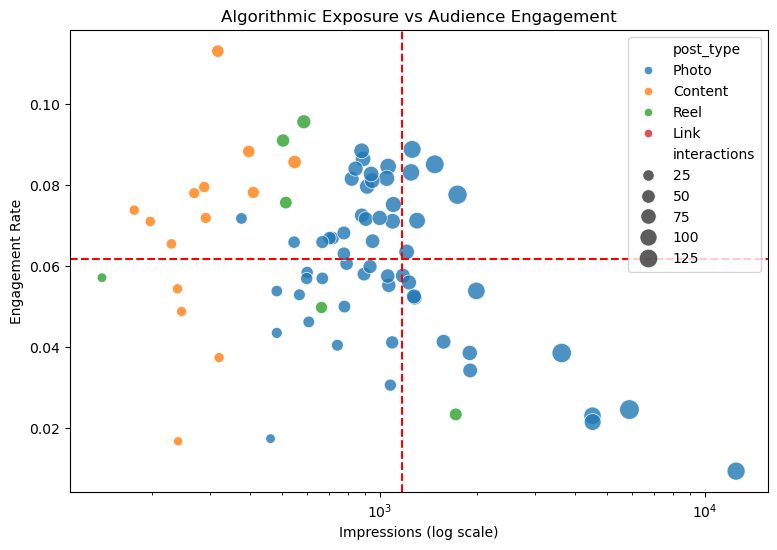

In [47]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="impressions",
    y="engagement_rate",
    hue="post_type",
    size="interactions",
    sizes=(40,200),
    alpha=0.8
)

plt.xscale("log")

plt.axvline(df["impressions"].mean(), color="red", linestyle="--")
plt.axhline(df["engagement_rate"].mean(), color="red", linestyle="--")

plt.xlabel("Impressions (log scale)")
plt.ylabel("Engagement Rate")

plt.title("Algorithmic Exposure vs Audience Engagement")

plt.show()

## Classifying Posts by Algorithmic Exposure and Audience Engagement
To better understand post performance, we classify posts based on two dimensions:
algorithmic exposure (impressions) and audience engagement (engagement rate). 
Posts are grouped into four categories using the median values of these metrics.

In [48]:
# compute medians
impressions_median = df["impressions"].median()
engagement_median = df["engagement_rate"].median()

# classify posts
def classify_post(row):
    if row["impressions"] >= impressions_median and row["engagement_rate"] >= engagement_median:
        return "Viral"
    elif row["impressions"] < impressions_median and row["engagement_rate"] >= engagement_median:
        return "Audience Favorite"
    elif row["impressions"] >= impressions_median and row["engagement_rate"] < engagement_median:
        return "Algorithm Pushed"
    else:
        return "Low Performance"

df["post_category"] = df.apply(classify_post, axis=1)

# counts per category
category_counts = df["post_category"].value_counts()

# relationship with post type
category_by_type = pd.crosstab(df["post_category"], df["post_type"])

category_counts, category_by_type

(post_category
 Low Performance      51
 Audience Favorite    21
 Algorithm Pushed     21
 Viral                18
 Name: count, dtype: int64,
 post_type          Content  Link  Photo  Reel
 post_category                                
 Algorithm Pushed         0     0     20     1
 Audience Favorite       10     0      8     3
 Low Performance          8     1     40     2
 Viral                    0     0     18     0)

In [49]:
df.sort_values("engagement_rate", ascending=False)[
    ["title","post_type","impressions","interactions","engagement_rate","post_category"]
].head(10)

,title,post_type,impressions,interactions,engagement_rate,post_category
28,"התרגשתי לקבל סקירה כזאת מעמיקה מ Danielle Eshel, שמזכירה לי את המקום שממנו נכתב הספר.\n\n״נחמץ לי הלב מהאירועים שהגיבורה עוברת… גם הייתי איתה בניצחונות שלה.״\n\nאחד הדברים שהיה לי הכי חשוב ליצור הוא רגע של הזדהות והטמעה בתוך אלי הגיבורה, להיכנס איתה לעולם אחר, למקום אחר, לראש שלה, ומתוך זה אולי להבין משהו קטן על עצמך.\n\nשמחה כל כך שההזדהות הזאת התרחשה אצל דניאל.\n \nומי שעוד לא קרא, הספר משתתף במבצעים של סטימצקי וצומת, \nולמי שמעדיף דיגיטל יש מבצע שווה במיוחד (עד היום) - לינק בתגובות.",Content,318.0,36.0,0.113208,Audience Favorite
51,"לדבר בקצרה זה לא בדיוק הצד החזק שלי.\n\nאבל ביקשו ממני לבחור רק שלושה דברים על #בין_המסדרונות,\nוהנה, הלכתי, וצימצמתי… ויצא סרטון! 🎥\n\nתודה ענקית ל־Orna landau - אורנה לנדאו על הארגון,\nול־Tamara Kreitler על הצילום המדויק והרגיש.\n\nולמי שהסרטון עושה חשק, הספר מחכה לכם בסטימצקי ובצומת,\nולמי שאוהב דיגיטל - גם באתר עברית (לינק בתגובות).",Reel,585.0,56.0,0.095726,Audience Favorite
44,האם יש מתכון להתאהבות?\nקטע קצר מתוך ״בין המסדרונות״...\n\nOrna landau - אורנה לנדאו\nהתחנה - בית הוצאה לאור,Reel,505.0,46.0,0.091089,Audience Favorite
49,"זאת הייתה שנה מיוחדת ומורכבת, השנה השלושים ושש בחיי, שקצת קשה לי להיפרד ממנה.\nואולי זה כי באופן כללי אני אדם שקצת קשה לו להיפרד.\n\nזאת הייתה שנה מלאה בתהפוכות, תשוקות חדשות ואסימונים שנפלו והתגלגלו והזיזו הרבה גלגלים במוח. \n\nשנה שבה הפכתי לאמא בפעם השנייה.\nשנה שבה למדתי לתמרן בין הפעוט שלי לבין התינוק שלי לבין רגשות האשם האימהיים שמובנים בי.\nשנה שאילצה אותי להתמודד עם הרבה אתגרים (והמון חוסר שינה) במערכת היחסים שלי, אבל גם קירבה אותי עוד לאורן.\nשנה שבה הוצאתי את הספר הראשון שלי, ״בין המסדרונות״, מעין לידה שלישית.\nשנה שבה הבנתי מה זה אומר להוציא ספר בישראל.\nשנה שבה פחדתי רגע לפני שהספר יצא כי הוא כבר לא יהיה רק פוטנציאל אלא יקבל קיום ממשי אצל קוראים.\nשנה שבה התרגשתי כל-כך לראות את התגובות של מי שקרא אותו ועד היום זה מרגש אותי נורא.\n\nזו הייתה שנה שבה חיפשתי את עצמי ולמדתי לדבר את הקול שלי.\nשנה שבה למדתי לעשות קרוסלות באינסטגרם (ומי יודע אולי בשנה הבאה, אני אפילו לא אפחד מטיקטוק ולא אחשוב שהוא סופה של האנושות).\nשנה שבה הרבה חברויות מפעם חזרו לחיי והרבה חברויות חדשות נוצרו ואני מברכת על כל אחת מהן.\nשנה שבה למדתי להיות נאמנה יותר לעצמי ולמה שעושה לי טוב בחיים האלה שעוברים מהר מדי.\nשנה שחיזקתי בה את האמונה שלי כי בסוף זה הדבר הכי חשוב בחיים האלה.\nושנה שבה למדתי לאזן את הפרפקציוניסטית שבי ולהילחם בה כשצריך ויש עוד הרבה עבודה לפניי.\n\nזהו יום ההולדת הראשון שאני חוגגת בלי סבתא שלי ז״ל.\nובכל זאת, אני שמחה מכל הטוב שכן יש סביבי, כי אני יודעת שהיא הייתה רוצה בכך. \nזו הייתה שנה שבה למדתי יותר ויותר להעריך את ה״כן״ ולהיות יותר סלחנית ל״לא״.\n\nאז תודה רבה לכל מי שבירך אותי ❤️. \nמאחלת לכולנו שנה שבה נהיה חזקים ומאוחדים וכמו שגיסתי החכמה תמיד אומרת, שנדע ליהנות מהדברים הפשוטים בחיים.\n\nבתמונה - אני ביומולדת לפני שנה, רגע לפני שילדתי את בני השני, בחולצה אדומה שמסמלת עבורי את התשוקה, היופי והמורכבות שבלהיות אישה.",Photo,1260.0,112.0,0.088889,Viral
45,"יש ימים שהעולם נראה גדול מדי ואני לא מצליחה להחזיק אותו בתוכי.\n\nאולי זה קשור לחוסר המטורף בשעות שינה?\nאולי זה הצורך להיות הכל ולהספיק הכל? \nלהיות אמא מספיק טובה, סופרת מספיק טובה, אבל גם לחזור ולעבוד בעבודה ״רצינית״.\n\nלפעמים שואלים אותי מתי אני חוזרת לעבודה ״אמיתית״?\nזה תמיד קצת מצחיק אותי (או מעציב, אבל בתכלס מצחיק ומעציב בדרך-כלל הולכים ביחד), כי מה שאני עושה עכשיו מרגיש לי אמיתי ורציני מאוד. \nוזה שזה לא עומד בסטנדרטים של עבודה מסודרת ומשכורת וודאית לא אומר שזה לא רציני. \nמה גם שאין באמת שום-דבר וודאי בחיים אבל זה כבר נושא אחר.\n\nאז אולי יקח קצת זמן למצוא בחזרה את האיזון הזה.\nלהתאזן בין האמא שאני רוצה להיות, לסופרת ולחוקרת.\nאבל זאת הבחירה שלי לא לפחד מהתהליך הזה, גם כשהוא מבולגן ולא עומד בסטנדרטים שגדלתי עליהם.\nגם כשאין כרגע עבודה ״רצינית״ וגם כשנראה לי שאני לא מספיקה את כל מה שאני רוצה, \nאני רוצה ללמוד להניח לדברים להיות מה שהם.\n\nבתמונה - אני מניחה רגע לאור לנצח את החושך.\n\n#אנשי_הגם_וגם",Photo,881.0,78.0,0.088536,Viral
87,כמה מרגש לקבל סקירה כזאת מעמיקה על #בין_המסדרונות!\n\nתודה ענקית ל Raz Calmanovici על הקריאה הרגי

## Posting Time and Engagement

We examine whether the hour of publication is associated with differences in post engagement and exposure.

In [50]:
# average performance by posting hour
hourly_performance = df.groupby("hour")[["engagement_rate","interactions","impressions"]].mean()

# number of posts per hour
posts_per_hour = df["hour"].value_counts().sort_index()

hourly_performance, posts_per_hour

(      engagement_rate  interactions  impressions
 hour                                            
 7            0.068711     39.000000   549.230769
 8            0.062469     61.192308  1168.769231
 9            0.060451     53.800000  1148.800000
 10           0.057547     61.000000  1060.000000
 11           0.016667      4.000000   240.000000
 12           0.088384     35.000000   396.000000
 15           0.084292     92.500000  1088.000000
 16                NaN           NaN          NaN
 17                NaN           NaN          NaN
 18           0.066890     53.333333   899.333333
 19           0.055497     60.400000  1754.263158
 20           0.053988     65.000000  1389.500000
 21                NaN           NaN          NaN
 22                NaN           NaN          NaN,
 hour
 7     16
 8     30
 9     13
 10     6
 11     3
 12     5
 15     4
 16     4
 17     1
 18     4
 19    20
 20     3
 21     1
 22     1
 Name: count, dtype: int64)

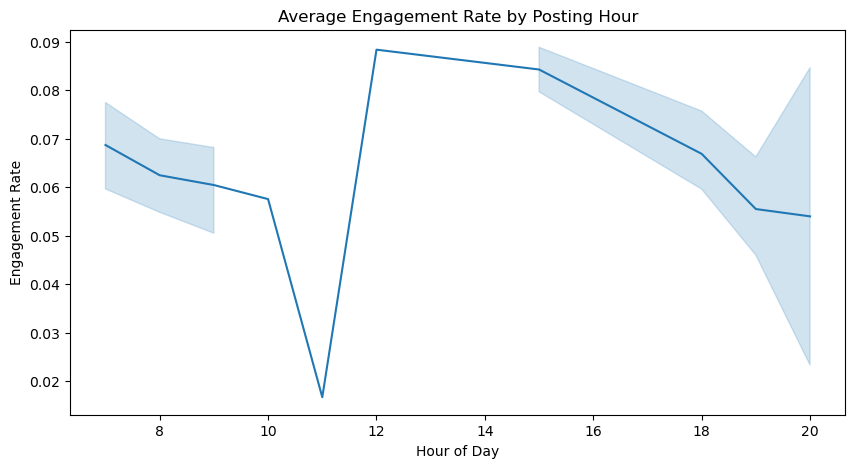

In [51]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="hour",
    y="engagement_rate",
    estimator="mean"
)

plt.title("Average Engagement Rate by Posting Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Engagement Rate")

plt.show()

### Interpretation

These analyses provide an initial view of whether posting time or day of week may influence engagement. 
However, results should be interpreted cautiously given the limited number of posts in some time slots.

In [53]:
df.shape
df.head()

,post_id,page_id,page_name,title,duration_sec_,publish_time,permalink,post_type,data_comment,date,...,saves,shares,viewers,average_seconds_viewed,seconds_viewed,hour,weekday,time,engagement_rate,post_category
0,10235051703501121,1461428297,Liz Izakson Mashal,"#זהו_זה_קורה!\n\nספטמבר מביא איתו התחלות חדשות.\n\nהילדים חוזרים למסגרות (סופסוף:)), שנה חדשה בפתח, אולי התחלתם אפילו לימודים או עבודה חדשה.\n\nוהנה עכשיו גם #בין_המסדרונות סופסוף נולד!\n\nוזה משמח ומרגש, וכן גם מפחיד מאוד:)\n\nשמחה לספר שאתר evrit - עברית בחרו בו כחלק מנבחרי החודש!\n\nאז אם בא לכם להיכנס לעולמה של אלי שחוקרת חיבורים בין אנשים בהווה ומתמודדת עם שאלות של זהות בפנימייה בעבר, אתם מוזמנים לרכוש אותו במבצע מיוחד (דיגיטלי או מודפס).\n\nומקווה שגם אתכם הוא יעביר מסע בין מסדרונות העבר להווה:)\n\nהלינק בתגובות 👇\n\nהתחנה - בית הוצאה לאור Orna Landau",0,2025-09-02 08:26:00,https://www.facebook.com/liz.izakson/posts/pfbid02aRsv9PY2BdwpgvNedqPGC7cxcsJdJ2HRSm2gfUrz6wLaRmpY3fBWVB6xXvi19zKSl,Photo,NaN,2025-09-02,...,0.0,6.0,1182.0,NaN,NaN,8,Tuesday,08:26:00,0.085193,Viral
1,10237757303779437,1461428297,Liz Izakson Mashal,"אתמול כתבתי כאן על החוויות ממפגש החתימות במודיעין, \nרגע לפני שהכול נסגר.\n\nאלה כמה רגעים מאחורי הקלעים.\n\nוהמחסן, שהוא חלק עיקרי מהשקט שאני צריכה לפני שאני ניגשת לאנשים:)\n\n#בין_המסדרונות #ספרים #ספרביכורים #מאחוריהקלעים #צומתספרים",0,2026-03-04 19:50:00,https://www.facebook.com/liz.izakson/posts/pfbid03SHJ5w8vVPpRtyDyxTrfK216NGTK3ZWqGEArXU1KcAWEEwxLo39A7UreykihMfxel,Content,NaN,2026-03-04,...,0.0,0.0,25.0,NaN,NaN,19,Wednesday,19:50:00,NaN,Low Performance
2,10237757281258874,1461428297,Liz Izakson Mashal,"⁨ ⁨ רגע לפני שהמלחמה התחילה והכל נסגר,\nוהתכנסנו שוב בממ״ד/מקלט,\nהספקתי לעמוד ליד ערימת הספרים שלי\nולדבר עם אנשים פנים אל פנים.\nבלי מסך בינינו.\n(אבל קודם ביליתי כמה דקות במחסן כדי להיטען,\nאין על מחסנים של חנויות ספרים )\n\nלמי שמתחשק קצת אסקפיזם, לינק לעותק הדיגיטלי בביו. \nקודי קופון להנחות נוספות: LIZIZ10, realbooks\n\n#בין_המסדרונות #ספרים #ספרותעברית #ספרביכורים #פנימייה \n\n‪‪@tzometsfarim‪@hatachana_publishing‪@lior_sharf‬harf‬harf⁩⁩",29,2026-03-04 19:49:00,https://www.facebook.com/reel/2482153035588530/,Reel,NaN,2026-03-04,...,0.0,1.0,127.0,7.255,1073.74,19,Wednesday,19:49:00,0.057143,Low Performance
3,10237734887059033,1461428297,Liz Izakson Mashal,"רגע לפני שהתחילה עוד מלחמה שסוגרת אותנו בבתים, \n\nמדביקה למסכים ומכניסה לדאגה קיומית,\n\nהספקתי לצאת לשטח ולנהל כמה שיחות פנים אל פנים עם קוראים.\n\nאני אוהבת לפגוש אנשים ככה. \nיש תמיד תחלופה אנרגטית שמתרחשת,\nוכשמדברים על ספרים, נחשפים רבדים.\n\nכי בסוף אנחנו בוחרים ספרים לפי מה שמדבר אותנו הכי עמוק.\n\nקודם כול גיליתי שמודיעין לא כזאת רחוקה ממני בשישי בבוקר.\n\nוהפעם גם יישמתי משהו שלמדתי על עצמי:\nלפני שאני פונה לאנשים, אני צריכה כמה רגעים לבד. לנשום.\nהמחסן של החנות הוא מקום אידיאלי לזה.\n\nאחרי שאני נטענת במחסן, אני עומדת ליד ערימת הספרים שלי \nוצופה באנשים שנכנסים ויוצאים.\n\nחנויות ספרים הן מקום בריחה.\nאז אני מנסה לקרוא שפת גוף.\nמי מחפש שקט, מי ממהר, ומי פתוח לשיחה על ספר חדש.\n\nכשאני כבר נכנסת למצב תודעה של “מחכים לגודו”, אני מכריחה את עצמי ליזום שיחה עם האדם הראשון שעובר לידי.\n\nהפעם זה היה בחור שלא מסתכל בעיניים. כזה שהעיניים שלו בורחות לכל הכיוונים.\nאני מחייכת ומספרת על #בין_המסדרונות. \nאני יודעת שהוא לא באמת מתעניין בו, הוא רוצה לספר לי על הצרות שלו בדייטים.\nואני מקשיבה, ותוהה אם להציע לו להסתכל יותר בעיניים.\n\nבזמן השיחה שלנו, שתי בחורות יוצאות מהתור לקופה ומתעניינות:\n“את כתבת ספר? על מה הספר?”\nאני מספרת. הן רוכשות. מבקשות הקדשה.\n\nואז האנרגיה הזאת, של האינטראקציות הראשונות, של ספר שמייצר חיבור ראשוני, מייצרת עוד אנרגיה לפנות, לשתף, להקשיב.\n\nאני עדיין בוחרת בזהירות למי לפנות. כדי לשמר אנרגיה.\nאני רוצה להקדיש תשומת לב לכל שיחה, וזה דורש משאבים.\n\nאמא ובת מגיעות עם רצון משותף לקרוא.\nהאמא מבקשת רגע לעיין.\nזה רגע לא קל כיוצרת - לראות את היצירה שלך נשפטת מול העיניים.\nאני נושמת ומזכירה לעצמי: היא טובה כמו שהיא.\nהיא מחליטה לקחת אותה ושואלת איך היה להיות בפנימיית בויאר.\n\nבחור גבוה עובר ושואל עד כמה הספר מבוסס על אירועים אמיתיים.\nזה בהשראתם, אני עונה. \nהוא התחי